# PatchCore Training Notebook (Pretrained ResNet18 Backbone)

This notebook runs a PatchCore sweep on the shared `64x64` 5% test-defect split using a frozen ImageNet-pretrained `ResNet18` backbone.

Workflow:
- load the shared processed wafer split
- build a frozen pretrained `ResNet18` PatchCore backbone
- sweep a few memory-bank / reduction settings
- save each variant to its own artifact folder
- compare variants in one summary table
- carry one selected variant into downstream plots and failure analysis


In [1]:
from pathlib import Path
import copy
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.evaluation import summarize_threshold_metrics, sweep_threshold_metrics
from wafer_defect.models.patchcore import PatchCoreModel
from wafer_defect.training.patchcore import build_memory_subset, collect_memory_bank


In [2]:
CONFIG_PATH = REPO_ROOT / "configs" / "training" / "train_patchcore_resnet18.toml"
config = load_toml(CONFIG_PATH)

PATCHCORE_SWEEP = [
    {"name": "mean_mb10k", "memory_bank_size": 10_000, "reduction": "mean", "topk_ratio": 0.10},
    {"name": "mean_mb50k", "memory_bank_size": 50_000, "reduction": "mean", "topk_ratio": 0.10},
    {"name": "topk_mb10k_r005", "memory_bank_size": 10_000, "reduction": "topk_mean", "topk_ratio": 0.05},
    {"name": "topk_mb50k_r005", "memory_bank_size": 50_000, "reduction": "topk_mean", "topk_ratio": 0.05},
    {"name": "topk_mb50k_r010", "memory_bank_size": 50_000, "reduction": "topk_mean", "topk_ratio": 0.10},
    {"name": "max_mb50k", "memory_bank_size": 50_000, "reduction": "max", "topk_ratio": 0.10},
]

SELECTED_VARIANT_NAME = None
AUTO_SELECT_METRIC = "f1"

# Optional quick smoke-run overrides:
# config["data"]["metadata_csv"] = "data/processed/x64/wm811k/metadata_dev.csv"
# config["run"]["output_dir"] = "artifacts/x64/patchcore_resnet18_dev"
# PATCHCORE_SWEEP = PATCHCORE_SWEEP[:2]

base_output_dir = REPO_ROOT / config["run"]["output_dir"]
config


{'run': {'output_dir': 'artifacts/x64/patchcore_resnet18', 'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct.csv',
  'image_size': 64,
  'batch_size': 64,
  'num_workers': 0},
 'training': {'device': 'auto'},
 'model': {'type': 'patchcore',
  'backbone_type': 'resnet18',
  'pretrained': True,
  'freeze_backbone': True,
  'backbone_input_size': 224,
  'normalize_imagenet': True,
  'memory_bank_size': 50000,
  'reduction': 'mean',
  'topk_ratio': 0.1,
  'query_chunk_size': 2048,
  'memory_chunk_size': 8192}}

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)


seed = int(config["run"]["seed"])
set_seed(seed)
device = resolve_device(config["training"].get("device", "auto"))
device


device(type='cuda')

In [4]:
image_size = int(config["data"].get("image_size", 64))
batch_size = int(config["data"].get("batch_size", 64))
num_workers = int(config["data"].get("num_workers", 0))
metadata_path = REPO_ROOT / config["data"]["metadata_csv"]
metadata = pd.read_csv(metadata_path)

display(metadata.head())
display(metadata["split"].value_counts().rename_axis("split").to_frame("count"))
display(metadata["is_anomaly"].value_counts().rename_axis("is_anomaly").to_frame("count"))

train_dataset = WaferMapDataset(metadata_path, split="train", image_size=image_size)
val_dataset = WaferMapDataset(metadata_path, split="val", image_size=image_size)
test_dataset = WaferMapDataset(metadata_path, split="test", image_size=image_size)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,data/processed/x64/wm811k/arrays/wafer_0000000...,none,none,0,train,Training,25,27
1,data/processed/x64/wm811k/arrays/wafer_0000001...,none,none,0,train,Training,55,66
2,data/processed/x64/wm811k/arrays/wafer_0000002...,none,none,0,train,Test,33,29
3,data/processed/x64/wm811k/arrays/wafer_0000003...,none,none,0,train,Training,25,26
4,data/processed/x64/wm811k/arrays/wafer_0000004...,none,none,0,train,Test,39,37


,count
split,
train,40000
test,5250
val,5000


,count
is_anomaly,
0,50000
1,250


train=40000, val=5000, test=5250


In [5]:
base_model_config = config["model"]
memory_bank_cache: dict[int, dict[str, object]] = {}


def build_patchcore_model(*, reduction: str, topk_ratio: float) -> PatchCoreModel:
    return PatchCoreModel(
        image_size=image_size,
        backbone_type=str(base_model_config.get("backbone_type", "resnet18")),
        use_batchnorm=bool(base_model_config.get("use_batchnorm", True)),
        pretrained=bool(base_model_config.get("pretrained", True)),
        freeze_backbone=bool(base_model_config.get("freeze_backbone", True)),
        backbone_input_size=int(base_model_config.get("backbone_input_size", 224)),
        normalize_imagenet=bool(base_model_config.get("normalize_imagenet", True)),
        reduction=str(reduction),
        topk_ratio=float(topk_ratio),
        query_chunk_size=int(base_model_config.get("query_chunk_size", 2048)),
        memory_chunk_size=int(base_model_config.get("memory_chunk_size", 8192)),
    ).to(device)


def get_memory_bank_info(memory_bank_size: int) -> dict[str, object]:
    if memory_bank_size not in memory_bank_cache:
        temp_model = build_patchcore_model(reduction="mean", topk_ratio=0.10)
        memory_subset = build_memory_subset(
            train_dataset,
            memory_bank_size=memory_bank_size,
            patches_per_image=temp_model.patches_per_image,
            seed=seed,
        )
        memory_loader = DataLoader(memory_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        memory_bank = collect_memory_bank(
            model=temp_model,
            dataloader=memory_loader,
            device=device,
            target_size=memory_bank_size,
            seed=seed,
        )
        memory_bank_cache[memory_bank_size] = {
            "memory_bank": memory_bank.cpu(),
            "memory_subset_images": len(memory_subset),
            "patches_per_image": int(temp_model.patches_per_image),
            "feature_dim": int(temp_model.feature_dim),
        }
        del temp_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return memory_bank_cache[memory_bank_size]


def collect_scores(model: PatchCoreModel, dataloader: DataLoader) -> pd.DataFrame:
    rows = []
    model.eval()
    with torch.inference_mode():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            scores = model(inputs).cpu().numpy()
            labels = labels.cpu().numpy()
            for score, label in zip(scores, labels):
                rows.append({"score": float(score), "is_anomaly": int(label)})
    return pd.DataFrame(rows)


print({
    "sweep_variants": [variant["name"] for variant in PATCHCORE_SWEEP],
    "base_output_dir": str(base_output_dir),
    "backbone_type": str(base_model_config.get("backbone_type", "resnet18")),
    "pretrained": bool(base_model_config.get("pretrained", True)),
})


{'sweep_variants': ['mean_mb10k', 'mean_mb50k', 'topk_mb10k_r005', 'topk_mb50k_r005', 'topk_mb50k_r010', 'max_mb50k'], 'base_output_dir': 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x64\\patchcore_resnet18', 'backbone_type': 'resnet18', 'pretrained': True}


In [6]:
base_output_dir.mkdir(parents=True, exist_ok=True)

sweep_rows = []
variant_outputs = {}
ranking_metrics = [AUTO_SELECT_METRIC, *[metric for metric in ["f1", "auroc", "auprc"] if metric != AUTO_SELECT_METRIC]]

for variant in PATCHCORE_SWEEP:
    variant_name = str(variant["name"])
    run_output_dir = base_output_dir / variant_name
    eval_dir = run_output_dir / "evaluation"
    run_output_dir.mkdir(parents=True, exist_ok=True)
    eval_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== PatchCore variant: {variant_name} ===")
    model = build_patchcore_model(reduction=variant["reduction"], topk_ratio=variant["topk_ratio"])
    memory_info = get_memory_bank_info(int(variant["memory_bank_size"]))
    model.set_memory_bank(memory_info["memory_bank"].to(device))

    run_config = copy.deepcopy(config)
    run_config["run"]["output_dir"] = run_output_dir.relative_to(REPO_ROOT).as_posix()
    run_config["model"]["memory_bank_size"] = int(variant["memory_bank_size"])
    run_config["model"]["reduction"] = str(variant["reduction"])
    run_config["model"]["topk_ratio"] = float(variant["topk_ratio"])

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "config": run_config,
        "memory_bank_size": int(model.memory_bank.shape[0]),
        "feature_dim": int(model.feature_dim),
        "patches_per_image": int(model.patches_per_image),
        "backbone_type": str(base_model_config.get("backbone_type", "resnet18")),
    }
    torch.save(checkpoint, run_output_dir / "best_model.pt")
    torch.save(checkpoint, run_output_dir / "last_model.pt")

    val_scores_df = collect_scores(model, val_loader)
    test_scores_df = collect_scores(model, test_loader)

    val_normal_scores = val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"]
    threshold = float(val_normal_scores.quantile(0.95))
    labels = test_scores_df["is_anomaly"].to_numpy()
    scores = test_scores_df["score"].to_numpy()

    metrics = summarize_threshold_metrics(labels, scores, threshold)
    threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)

    summary = {
        "name": variant_name,
        "memory_bank_size": int(model.memory_bank.shape[0]),
        "memory_subset_images": int(memory_info["memory_subset_images"]),
        "patches_per_image": int(memory_info["patches_per_image"]),
        "feature_dim": int(memory_info["feature_dim"]),
        "reduction": str(variant["reduction"]),
        "topk_ratio": float(variant["topk_ratio"]),
        "threshold": threshold,
        "precision": float(metrics["precision"]),
        "recall": float(metrics["recall"]),
        "f1": float(metrics["f1"]),
        "auroc": float(metrics["auroc"]),
        "auprc": float(metrics["auprc"]),
        "best_sweep_threshold": float(best_sweep["threshold"]),
        "best_sweep_precision": float(best_sweep["precision"]),
        "best_sweep_recall": float(best_sweep["recall"]),
        "best_sweep_f1": float(best_sweep["f1"]),
        "predicted_anomalies": int(metrics["predicted_anomalies"]),
        "output_dir": run_output_dir.relative_to(REPO_ROOT).as_posix(),
    }

    val_scores_df.to_csv(eval_dir / "val_scores.csv", index=False)
    test_scores_df.to_csv(eval_dir / "test_scores.csv", index=False)
    threshold_sweep_df.to_csv(eval_dir / "threshold_sweep.csv", index=False)
    with (run_output_dir / "summary.json").open("w", encoding="utf-8") as handle:
        json.dump(summary, handle, indent=2)

    print(summary)
    sweep_rows.append(summary)
    variant_outputs[variant_name] = {
        "summary": summary,
        "val_scores_df": val_scores_df,
        "test_scores_df": test_scores_df,
        "threshold_sweep_df": threshold_sweep_df,
        "metrics": metrics,
        "best_sweep": best_sweep,
        "output_dir": run_output_dir,
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sweep_results_df = pd.DataFrame(sweep_rows).sort_values(ranking_metrics, ascending=False).reset_index(drop=True)
sweep_results_df.to_csv(base_output_dir / "patchcore_sweep_results.csv", index=False)

if SELECTED_VARIANT_NAME is not None:
    selected_variant_name = SELECTED_VARIANT_NAME
else:
    selected_variant_name = str(sweep_results_df.iloc[0]["name"])

selected_row = sweep_results_df.loc[sweep_results_df["name"] == selected_variant_name].iloc[0].to_dict()
with (base_output_dir / "patchcore_sweep_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(
        {
            "selected_variant_name": selected_variant_name,
            "auto_select_metric": AUTO_SELECT_METRIC,
            "ranking_metrics": ranking_metrics,
            "selected_row": selected_row,
            "results": sweep_rows,
        },
        handle,
        indent=2,
    )

print(f"Selected variant for downstream plots: {selected_variant_name}")
display(sweep_results_df)



=== PatchCore variant: mean_mb10k ===
{'name': 'mean_mb10k', 'memory_bank_size': 10000, 'memory_subset_images': 205, 'patches_per_image': 49, 'feature_dim': 512, 'reduction': 'mean', 'topk_ratio': 0.1, 'threshold': 0.3942557469010353, 'precision': 0.34513274336283184, 'recall': 0.468, 'f1': 0.39728353140916806, 'auroc': 0.8311908000000001, 'auprc': 0.4096822813926394, 'best_sweep_threshold': 0.4057290852069855, 'best_sweep_precision': 0.470873786407767, 'best_sweep_recall': 0.388, 'best_sweep_f1': 0.42543859649073273, 'predicted_anomalies': 339, 'output_dir': 'artifacts/x64/patchcore_resnet18/mean_mb10k'}

=== PatchCore variant: mean_mb50k ===
{'name': 'mean_mb50k', 'memory_bank_size': 50000, 'memory_subset_images': 1021, 'patches_per_image': 49, 'feature_dim': 512, 'reduction': 'mean', 'topk_ratio': 0.1, 'threshold': 0.36278578191995625, 'precision': 0.34593023255813954, 'recall': 0.476, 'f1': 0.4006734006734007, 'auroc': 0.8422664, 'auprc': 0.4107294434923713, 'best_sweep_threshold'

,name,memory_bank_size,memory_subset_images,patches_per_image,feature_dim,reduction,topk_ratio,threshold,precision,recall,f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1,predicted_anomalies,output_dir
0,mean_mb50k,50000,1021,49,512,mean,0.10,0.362786,0.345930,0.476,0.400673,0.842266,0.410729,0.369899,0.450820,0.440,0.445344,344,artifacts/x64/patchcore_resnet18/mean_mb50k
1,mean_mb10k,10000,205,49,512,mean,0.10,0.394256,0.345133,0.468,0.397284,0.831191,0.409682,0.405729,0.470874,0.388,0.425439,339,artifacts/x64/patchcore_resnet18/mean_mb10k
2,topk_mb50k_r010,50000,1021,49,512,topk_mean,0.10,0.466829,0.296875,0.380,0.333333,0.803171,0.329613,0.481863,0.416667,0.320,0.361991,320,artifacts/x64/patchcore_resnet18/topk_mb50k_r010
3,topk_mb10k_r005,10000,205,49,512,topk_mean,0.05,0.517284,0.290520,0.380,0.329289,0.795090,0.323395,0.544604,0.486667,0.292,0.365000,327,artifacts/x64/patchcore_resnet18/topk_mb10k_r005
4,topk_mb50k_r005,50000,1021,49,512,topk_mean,0.05,0.478494,0.291667,0.364,0.323843,0.795596,0.318155,0.488743,0.364444,0.328,0.345263,312,artifacts/x64/patchcore_resnet18/topk_mb50k_r005
5,max_mb50k,50000,1021,49,512,max,0.10,0.496377,0.281553,0.348,0.311270,0.786144,0.303307,0.506390,0.358140,0.308,0.331183,309,artifacts/x64/patchcore_resnet18/max_mb50k


In [7]:
selected_variant = variant_outputs[selected_variant_name]
output_dir = selected_variant["output_dir"]
summary = selected_variant["summary"]
val_scores_df = selected_variant["val_scores_df"]
test_scores_df = selected_variant["test_scores_df"]
threshold_sweep_df = selected_variant["threshold_sweep_df"]
metrics = selected_variant["metrics"]
best_sweep = selected_variant["best_sweep"]
threshold = float(summary["threshold"])

metrics_df = pd.DataFrame(
    [
        {"metric": "precision", "value": metrics["precision"]},
        {"metric": "recall", "value": metrics["recall"]},
        {"metric": "f1", "value": metrics["f1"]},
        {"metric": "auroc", "value": metrics["auroc"]},
        {"metric": "auprc", "value": metrics["auprc"]},
        {"metric": "threshold", "value": threshold},
    ]
)

display(metrics_df)
display(pd.DataFrame(metrics["confusion_matrix"], index=["true_normal", "true_anomaly"], columns=["pred_normal", "pred_anomaly"]))
print(f"Selected variant: {selected_variant_name}")
print(f"Best sweep threshold: {best_sweep['threshold']:.6f} | precision={best_sweep['precision']:.4f}, recall={best_sweep['recall']:.4f}, f1={best_sweep['f1']:.4f}")


,metric,value
0,precision,0.345930
1,recall,0.476000
2,f1,0.400673
3,auroc,0.842266
4,auprc,0.410729
5,threshold,0.362786


,pred_normal,pred_anomaly
true_normal,4775,225
true_anomaly,131,119


Selected variant: mean_mb50k
Best sweep threshold: 0.369899 | precision=0.4508, recall=0.4400, f1=0.4453


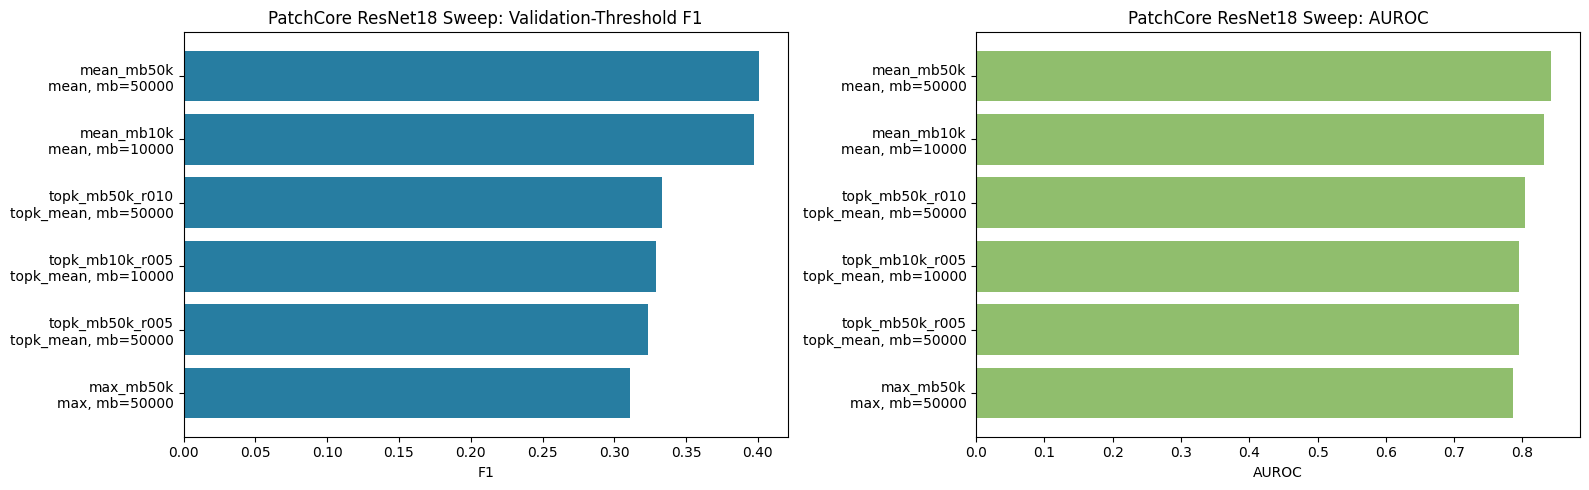

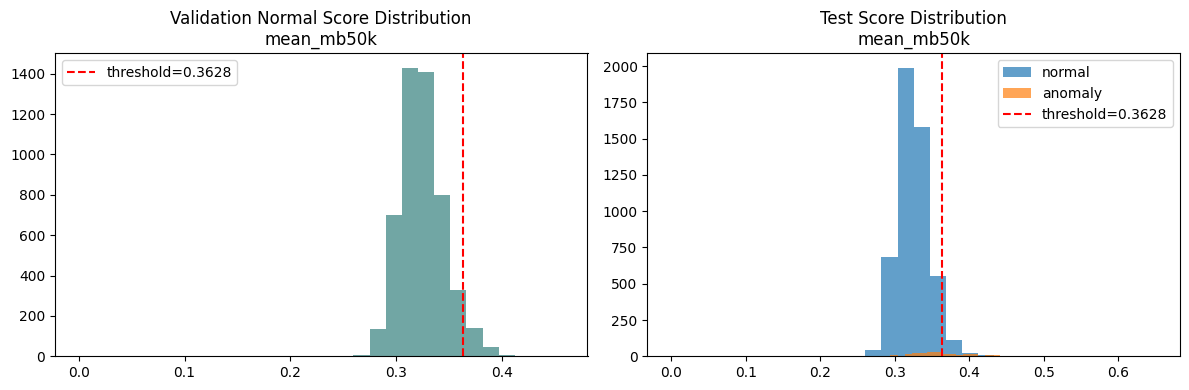

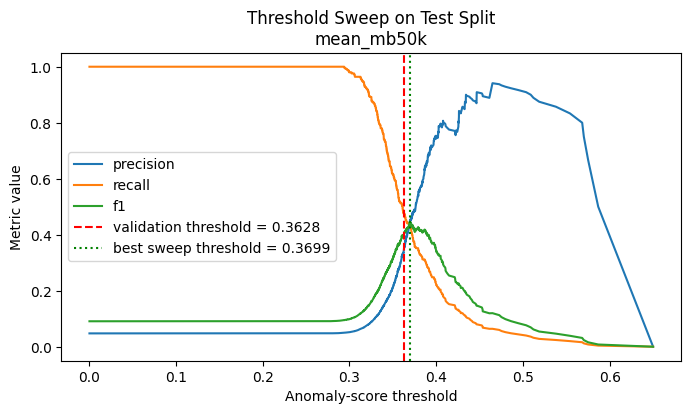

In [8]:
plot_df = sweep_results_df.copy()
plot_df["label"] = plot_df["name"] + "\n" + plot_df["reduction"] + ", mb=" + plot_df["memory_bank_size"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(plot_df["label"], plot_df["f1"], color="#277da1")
axes[0].set_title("PatchCore ResNet18 Sweep: Validation-Threshold F1")
axes[0].set_xlabel("F1")
axes[0].invert_yaxis()

axes[1].barh(plot_df["label"], plot_df["auroc"], color="#90be6d")
axes[1].set_title("PatchCore ResNet18 Sweep: AUROC")
axes[1].set_xlabel("AUROC")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(val_scores_df["score"], bins=30, alpha=0.8, color="#4d908e")
axes[0].axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
axes[0].set_title(f"Validation Normal Score Distribution\n{selected_variant_name}")
axes[0].legend()

axes[1].hist(test_scores_df[test_scores_df["is_anomaly"] == 0]["score"], bins=30, alpha=0.7, label="normal")
axes[1].hist(test_scores_df[test_scores_df["is_anomaly"] == 1]["score"], bins=30, alpha=0.7, label="anomaly")
axes[1].axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
axes[1].set_title(f"Test Score Distribution\n{selected_variant_name}")
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], label="precision")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], label="recall")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], label="f1")
plt.axvline(threshold, color="red", linestyle="--", label=f"validation threshold = {threshold:.4f}")
plt.axvline(best_sweep["threshold"], color="green", linestyle=":", label=f"best sweep threshold = {best_sweep['threshold']:.4f}")
plt.title(f"Threshold Sweep on Test Split\n{selected_variant_name}")
plt.xlabel("Anomaly-score threshold")
plt.ylabel("Metric value")
plt.legend()
plt.show()


## Failure Analysis

This section attaches the selected ResNet18 PatchCore scores to the test metadata and highlights the main false-positive and false-negative patterns.


In [9]:
analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
analysis_df["score"] = test_scores_df.reset_index(drop=True)["score"]
analysis_df["predicted_anomaly"] = (analysis_df["score"] > threshold).astype(int)

analysis_df["error_type"] = "tn"
analysis_df.loc[(analysis_df["is_anomaly"] == 0) & (analysis_df["predicted_anomaly"] == 1), "error_type"] = "fp"
analysis_df.loc[(analysis_df["is_anomaly"] == 1) & (analysis_df["predicted_anomaly"] == 0), "error_type"] = "fn"
analysis_df.loc[(analysis_df["is_anomaly"] == 1) & (analysis_df["predicted_anomaly"] == 1), "error_type"] = "tp"

error_summary_df = (
    analysis_df.groupby("error_type")
    .agg(count=("error_type", "size"), mean_score=("score", "mean"))
    .reindex(["tp", "fn", "fp", "tn"])
)

defect_recall_df = (
    analysis_df[analysis_df["is_anomaly"] == 1]
    .groupby("defect_type")
    .agg(count=("defect_type", "size"), detected=("predicted_anomaly", "sum"), mean_score=("score", "mean"))
    .sort_values(["detected", "count"], ascending=[False, False])
)
defect_recall_df["recall"] = defect_recall_df["detected"] / defect_recall_df["count"]

print(f"Failure analysis variant: {selected_variant_name}")
display(error_summary_df)
display(defect_recall_df)
analysis_df.head()


Failure analysis variant: mean_mb50k


,count,mean_score
error_type,,
tp,119,0.412849
fn,131,0.337854
fp,225,0.378711
tn,4775,0.322284


,count,detected,mean_score,recall
defect_type,,,,
Edge-Ring,84,44,0.370883,0.523810
Center,50,24,0.372524,0.480000
Edge-Loc,53,14,0.351275,0.264151
Loc,34,14,0.373996,0.411765
Scratch,15,9,0.388993,0.600000
Donut,7,7,0.457941,1.000000
Random,5,5,0.447006,1.000000
Near-full,2,2,0.499259,1.000000


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width,score,predicted_anomaly,error_type
0,data/processed/x64/wm811k/arrays/wafer_0045000...,none,none,0,test,Training,33,37,0.316155,0,tn
1,data/processed/x64/wm811k/arrays/wafer_0045001...,none,none,0,test,Training,27,25,0.345803,0,tn
2,data/processed/x64/wm811k/arrays/wafer_0045002...,none,none,0,test,Test,41,42,0.305293,0,tn
3,data/processed/x64/wm811k/arrays/wafer_0045003...,none,none,0,test,Training,27,27,0.352959,0,tn
4,data/processed/x64/wm811k/arrays/wafer_0045004...,none,none,0,test,Test,30,34,0.296663,0,tn
